In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
pd.set_option('display.max_rows', None)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
file_path = 'C:/python_course/final_project/eunbi'

# 거래량 변화

### 분기별 법정동 거래율 변화

In [5]:
trans_df = pd.read_csv(file_path+'/transactions_total.csv', encoding = 'cp949')
trans_df.head()

,시군구,법정동,유형,용도지역,전용/연면적(㎡),건축물주용도,거래금액(만원),층,계약연월
0,경기도 성남시 분당구,구미동,집합,근린상업,30.31,제2종근린생활,69500,1.0,2023-01
1,경기도 성남시 분당구,금곡동,집합,중심상업,45.24,제2종근린생활,69000,1.0,2023-01
2,경기도 성남시 분당구,서현동,집합,근린상업,19.94,교육연구,9753,2.0,2023-01
3,경기도 성남시 분당구,서현동,집합,근린상업,75.66,제1종근린생활,37000,NaN,2023-01
4,경기도 성남시 분당구,서현동,집합,근린상업,75.66,제1종근린생활,37000,2.0,2023-01


In [8]:
trans_df['계약연월'] = pd.to_datetime(trans_df['계약연월'], format='%Y-%m')
trans_df['분기'] = trans_df['계약연월'].dt.to_period('Q')

In [ ]:
#분기별 법정동 거래량 비율
result = trans_df.groupby('분기')[['시군구', '법정동']].value_counts(normalize=True) * 100
result

분기      시군구          법정동 
2023Q1  경기도 성남시 분당구  서현동     30.733945
                     구미동     16.513761
                     정자동      7.339450
        경기도 성남시 수정구  창곡동      7.339450
        경기도 성남시 분당구  야탑동      5.963303
                     삼평동      5.045872
        경기도 성남시 중원구  상대원동     3.211009
                     성남동      3.211009
        경기도 성남시 분당구  수내동      2.752294
                     이매동      2.752294
        경기도 성남시 수정구  태평동      2.752294
        경기도 성남시 분당구  금곡동      1.834862
        경기도 성남시 중원구  금광동      1.834862
                     도촌동      1.834862
        경기도 성남시 수정구  고등동      1.834862
        경기도 성남시 분당구  운중동      1.376147
        경기도 성남시 중원구  하대원동     1.376147
        경기도 성남시 수정구  신흥동      0.917431
                     산성동      0.458716
        경기도 성남시 중원구  여수동      0.458716
        경기도 성남시 분당구  판교동      0.458716
2023Q2  경기도 성남시 분당구  정자동     17.132867
                     서현동     12.937063
                     수내동     10.489510
                     구미동     10.139860

In [31]:
# 분기별 거래량(비율)이 많은 법정동 top12(2023년~2025년 = 총 12분기)
top12 = result.groupby('분기').nlargest(12)
top12

분기      분기      시군구          법정동 
2023Q1  2023Q1  경기도 성남시 분당구  서현동     30.733945
                             구미동     16.513761
                             정자동      7.339450
                경기도 성남시 수정구  창곡동      7.339450
                경기도 성남시 분당구  야탑동      5.963303
                             삼평동      5.045872
                경기도 성남시 중원구  상대원동     3.211009
                             성남동      3.211009
                경기도 성남시 분당구  수내동      2.752294
                             이매동      2.752294
                경기도 성남시 수정구  태평동      2.752294
                경기도 성남시 분당구  금곡동      1.834862
2023Q2  2023Q2  경기도 성남시 분당구  정자동     17.132867
                             서현동     12.937063
                             수내동     10.489510
                             구미동     10.139860
                             삼평동      8.391608
                경기도 성남시 수정구  창곡동      6.293706
                경기도 성남시 분당구  금곡동      4.195804
                경기도 성남시 중원구  상대원동     3.846154
                경기도 성남시 분당

In [ ]:
#전체 기간(2023~2025년) 동안 거래량 상위 그룹에 속한 법정동 확인
freq = (
    top12
    .reset_index(level=0, drop=True) 
    .reset_index()
    .value_counts(['시군구', '법정동'])
)

freq # (분당구) 서현동, 구미동, 정자동, 야탑동, 삼평동, 수내동, 금곡동 (수정구) 창곡동

시군구          법정동 
경기도 성남시 분당구  서현동     12
             구미동     12
             정자동     12
경기도 성남시 수정구  창곡동     12
경기도 성남시 분당구  야탑동     12
             삼평동     12
             수내동     12
             금곡동     12
경기도 성남시 중원구  성남동     10
             상대원동     8
경기도 성남시 분당구  이매동      6
             운중동      4
경기도 성남시 수정구  신흥동      4
경기도 성남시 분당구  백현동      3
             대장동      3
경기도 성남시 중원구  금광동      2
경기도 성남시 수정구  수진동      2
             태평동      1
             고등동      1
경기도 성남시 중원구  도촌동      1
경기도 성남시 분당구  판교동      1
경기도 성남시 중원구  여수동      1
경기도 성남시 분당구  분당동      1
Name: count, dtype: int64

In [40]:
result_df = result.rename('분기별 비율').reset_index()

top_target = ['서현동', '구미동', '정자동', '야탑동', '삼평동', '수내동', '금곡동', '창곡동']
result_df_sub = result_df[result_df['법정동'].isin(top_target)]

In [43]:
pivot = result_df_sub.pivot_table(
    index='분기', # 행
    columns='법정동', # 열
    values='분기별 비율' # 값
)

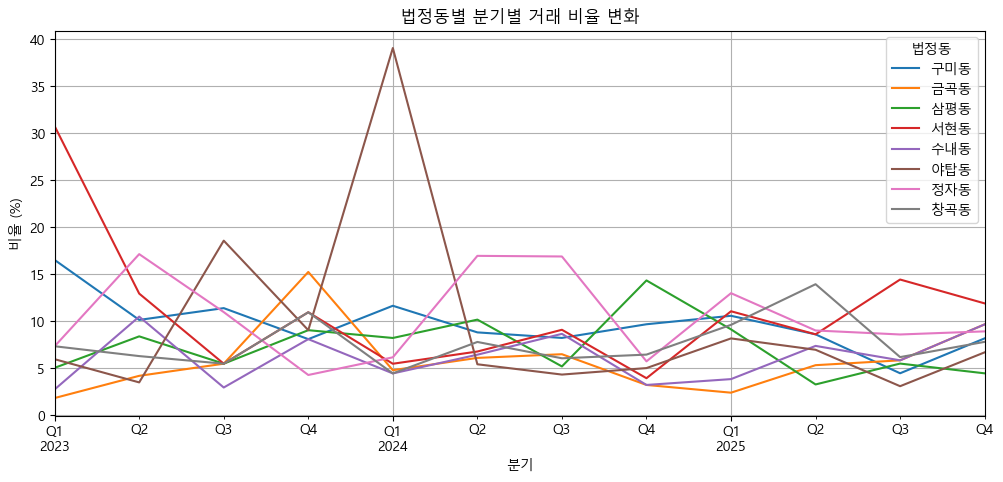

In [49]:
pivot.plot(figsize=(12,5), marker='')
plt.title('법정동별 분기별 거래 비율 변화')
plt.ylabel('비율 (%)')
plt.xlabel('분기')
plt.xticks(rotation=0)
plt.grid()
plt.show()

#### 참고(도메인 조사)

| 지역명 | 위험 수준 | 위험 유형 | 주요 원인 및 현황 |
| :--- | :---: | :--- | :--- |
| **삼평동** | **매우 높음** | 업무/상업 복합 | 판교테크노밸리의 중심지로, 극도로 높은 임대료 때문에 거대 자본(프랜차이즈, 대형 법인) 위주로 상권 재편 완료 |
| **정자동** | **높음** | 상업 젠트리피케이션 | 네이버, 두산 등 대기업 인접 및 카페거리의 고급화로 인해 소규모 개인 상점의 진입 장벽이 매우 높음 |
| **백현동** | **높음** | 상업 젠트리피케이션 | 판교역 인근 상업 시설의 팽창과 카페거리의 브랜드화로 인해 기존 영세 상권의 입지가 지속적으로 축소 |
| **서현동** | **보통/주의** | 상업 고착화 | 분당 최대의 노후 상권이나, 리모델링 및 업종 전환 시점에서 임대료가 크게 상승하여 업종 교체 주기 가팔라짐 |
| **수내동** | **보통** | 주거/상업 안정 | 전형적인 배후 주거지 상권으로 안정적이나, 학원가와 연계된 특정 업종의 임대료 경쟁이 치열함 |
| **야탑동** | **보통** | 교통 요충지 상권 | 터미널과 병원 등 유동인구가 확실하여 임대료가 견고함. 급격한 젠트리피케이션보다는 완만한 상권 변화 양상 |
| **창곡동** | **안정/유지** | 위례신도시 | 신도시 조성 초기부터 이미 높은 임대료가 형성됨. 내몰림보다는 공실률과 임대료 사이의 조정기를 거치는 단계 |
| **금곡동** | **낮음/안정** | 주거 중심 | 미금역 인근 상권을 제외하면 안정적인 주거지 위주. 대규모 개발 이슈가 적어 위험도 낮음 |
| **구미동** | **낮음/안정** | 주거 중심 | 분당 남단의 성숙된 주거지로, 상권 변화가 완만하며 젠트리피케이션 징후가 가장 적은 편에 속함 |

※거래량과 연관성이 예상되는 변수들: 공시지가 상승률(임대료), 프랜차이즈 침투율, 업종 교체 주기, 유동인구, 상권 활력도(공실률)


#### 전체기간 구별 용도지역 분포

<Axes: xlabel='용도지역'>

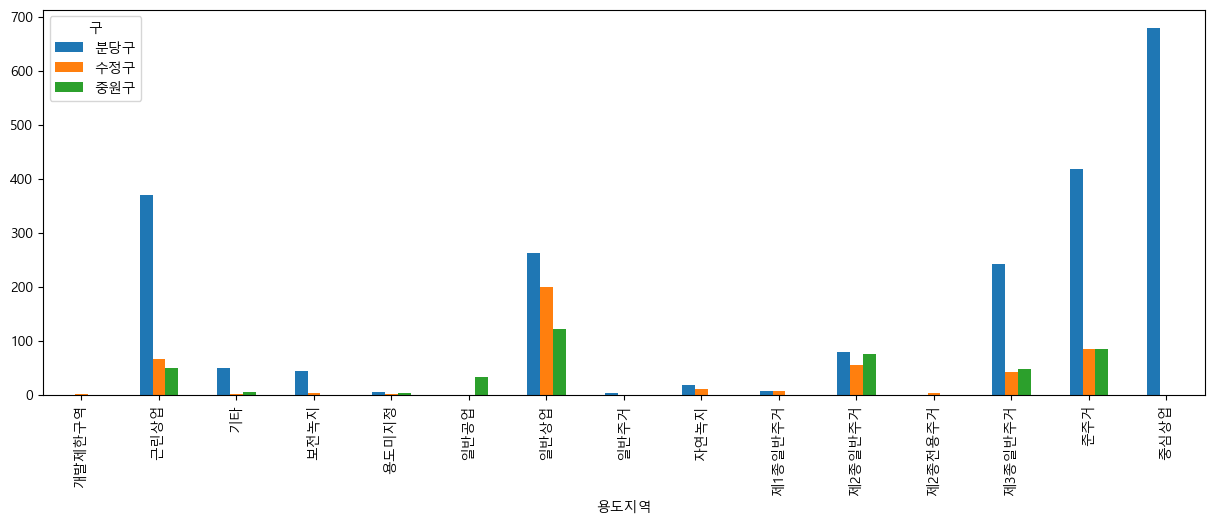

In [ ]:
pivot = (
    trans_df[trans_df['시군구'].str.contains('분당구|수정구|중원구', na=False)]
    .assign(구=lambda x: x['시군구'].str.extract('(분당구|수정구|중원구)'))
    .groupby(['구', '용도지역'])
    .size()
    .unstack(fill_value=0)
)

pivot.T.plot(kind='bar', figsize=(15,5))

#### 전체기간 구별 건축물주용도

<Axes: xlabel='건축물주용도'>

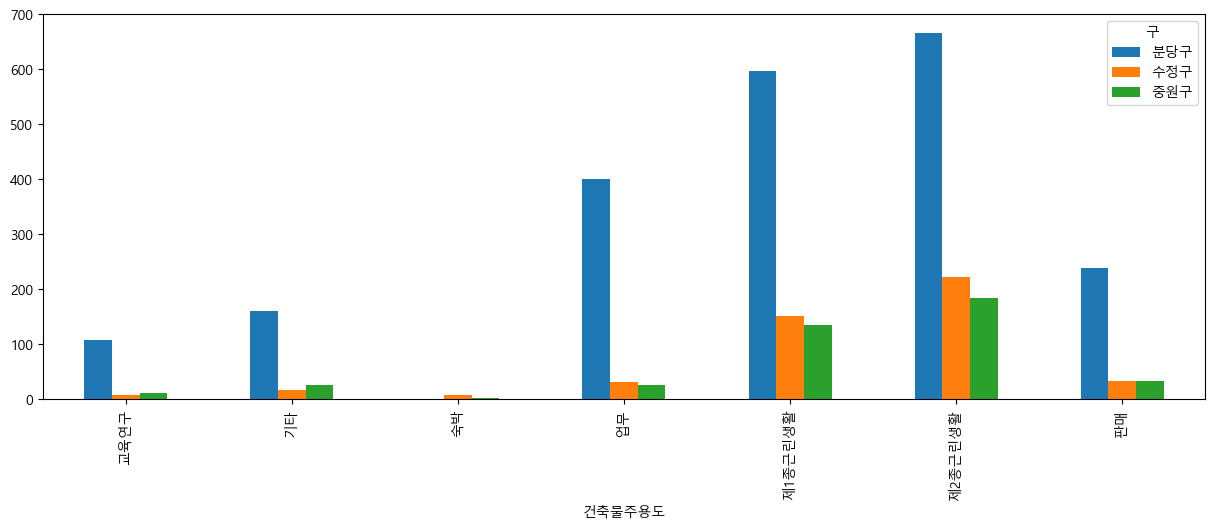

In [17]:
pivot = (
    trans_df[trans_df['시군구'].str.contains('분당구|수정구|중원구', na=False)]
    .assign(구=lambda x: x['시군구'].str.extract('(분당구|수정구|중원구)'))
    .groupby(['구', '건축물주용도'])
    .size()
    .unstack(fill_value=0)
)

pivot.T.plot(kind='bar', figsize=(15,5))

# 신규기업 증가율

In [ ]:
corp_df = pd.read_csv(file_path+'/new_corp_total.csv', encoding = 'utf-8')
corp_df.head()


,date,sido_nm,sigun_nm,admi_nm,dong_code,induty_pri_cd,induty_pri_nm,induty_med_cd,induty_med_nm,ncr_crp_comp_cn
0,2023-01,경기,성남시 분당구,구미1동,4113566500,10G0000000,G 도매 및 소매업(45~47),10G4600000,도매 및 상품 중개업,3
1,2023-01,경기,성남시 분당구,구미1동,4113566500,10J0000000,J 정보통신업(58~63),10J5800000,출판업,1
2,2023-01,경기,성남시 분당구,구미1동,4113566500,10J0000000,J 정보통신업(58~63),10J6200000,"컴퓨터 프로그래밍, 시스템 통합 및 관리업",1
3,2023-01,경기,성남시 분당구,구미1동,4113566500,10L0000000,L 부동산업(68),10L6800000,부동산업,1
4,2023-01,경기,성남시 분당구,구미1동,4113566500,10N0000000,"N 사업시설 관리, 사업 지원 및 임대 서비스업(74~76)",10N7400000,사업시설 관리 및 조경 서비스업,1


<Axes: xlabel='date'>

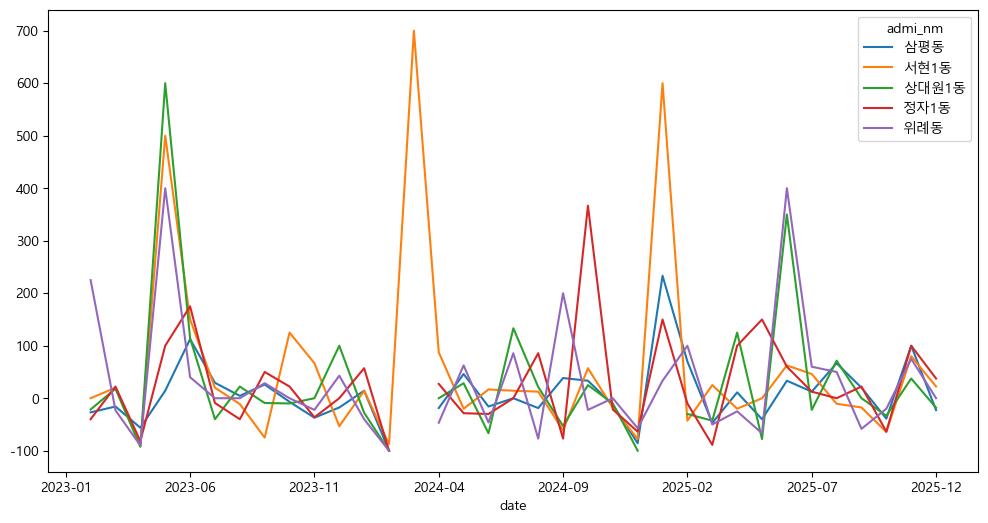

In [ ]:
pivot_df = (
    corp_df
    .pivot_table(
        index='date',
        columns='admi_nm',
        values='ncr_crp_comp_cn',
        aggfunc='sum',
        fill_value=0
    )
    .sort_index()
)

growth_rate = pivot_df.pct_change() * 100

top_dongs = pivot_df.sum().nlargest(5).index
growth_rate[top_dongs].plot(figsize=(12,6))


# 매출액 변화율

## 지역별 매출 비교

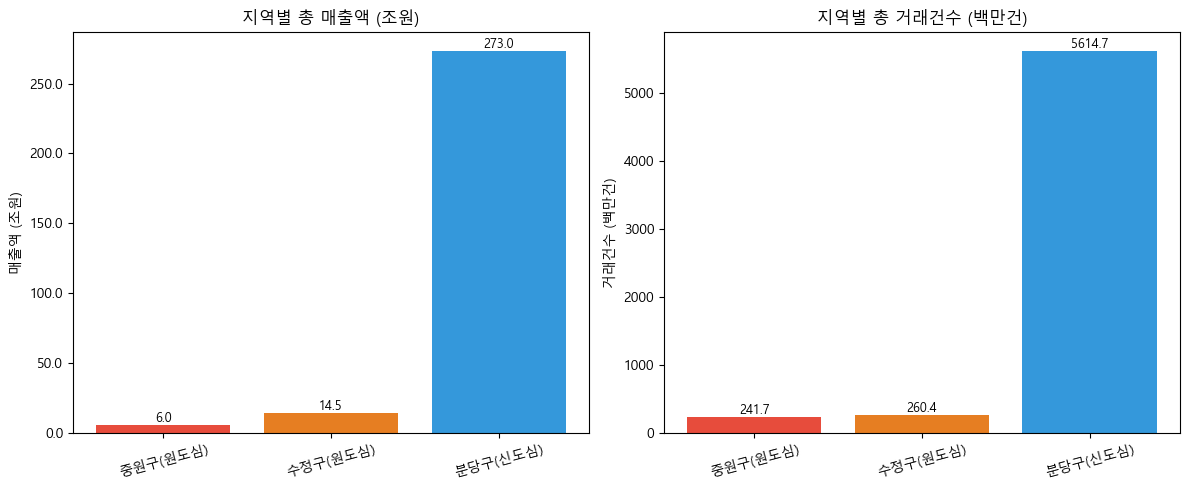

,지역,총매출액,총거래건수,평균매출액
0,중원구(원도심),6.024834e+12,2.417383e+08,2.561654e+05
1,수정구(원도심),1.450853e+13,2.603976e+08,8.396504e+05
2,분당구(신도심),2.729911e+14,5.614669e+09,5.875255e+06


In [46]:
SALES_PATH = f'{file_path}/전처리완료_카드(매출).csv'

region_map = {'41131': '중원구(원도심)', '41133': '수정구(원도심)', '41135': '분당구(신도심)'}

region_df = con.execute(f"""
    SELECT
        CAST(cty_rgn_no AS VARCHAR) AS cty_rgn_no,
        SUM(amt) AS 총매출액,
        SUM(cnt) AS 총거래건수,
        AVG(amt) AS 평균매출액
    FROM read_csv_auto('{SALES_PATH}', delim=',', header=True)
    WHERE CAST(cty_rgn_no AS VARCHAR) IN ('41131', '41133', '41135')
    GROUP BY cty_rgn_no
    ORDER BY cty_rgn_no
""").df()
region_df['지역'] = region_df['cty_rgn_no'].map(region_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#e74c3c', '#e67e22', '#3498db']

axes[0].bar(region_df['지역'], region_df['총매출액'] / 1e12, color=colors)
axes[0].set_title('지역별 총 매출액 (조원)')
axes[0].set_ylabel('매출액 (조원)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

axes[1].bar(region_df['지역'], region_df['총거래건수'] / 1e6, color=colors)
axes[1].set_title('지역별 총 거래건수 (백만건)')
axes[1].set_ylabel('거래건수 (백만건)')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
display(region_df[['지역', '총매출액', '총거래건수', '평균매출액']])

## 월별 매출 추이

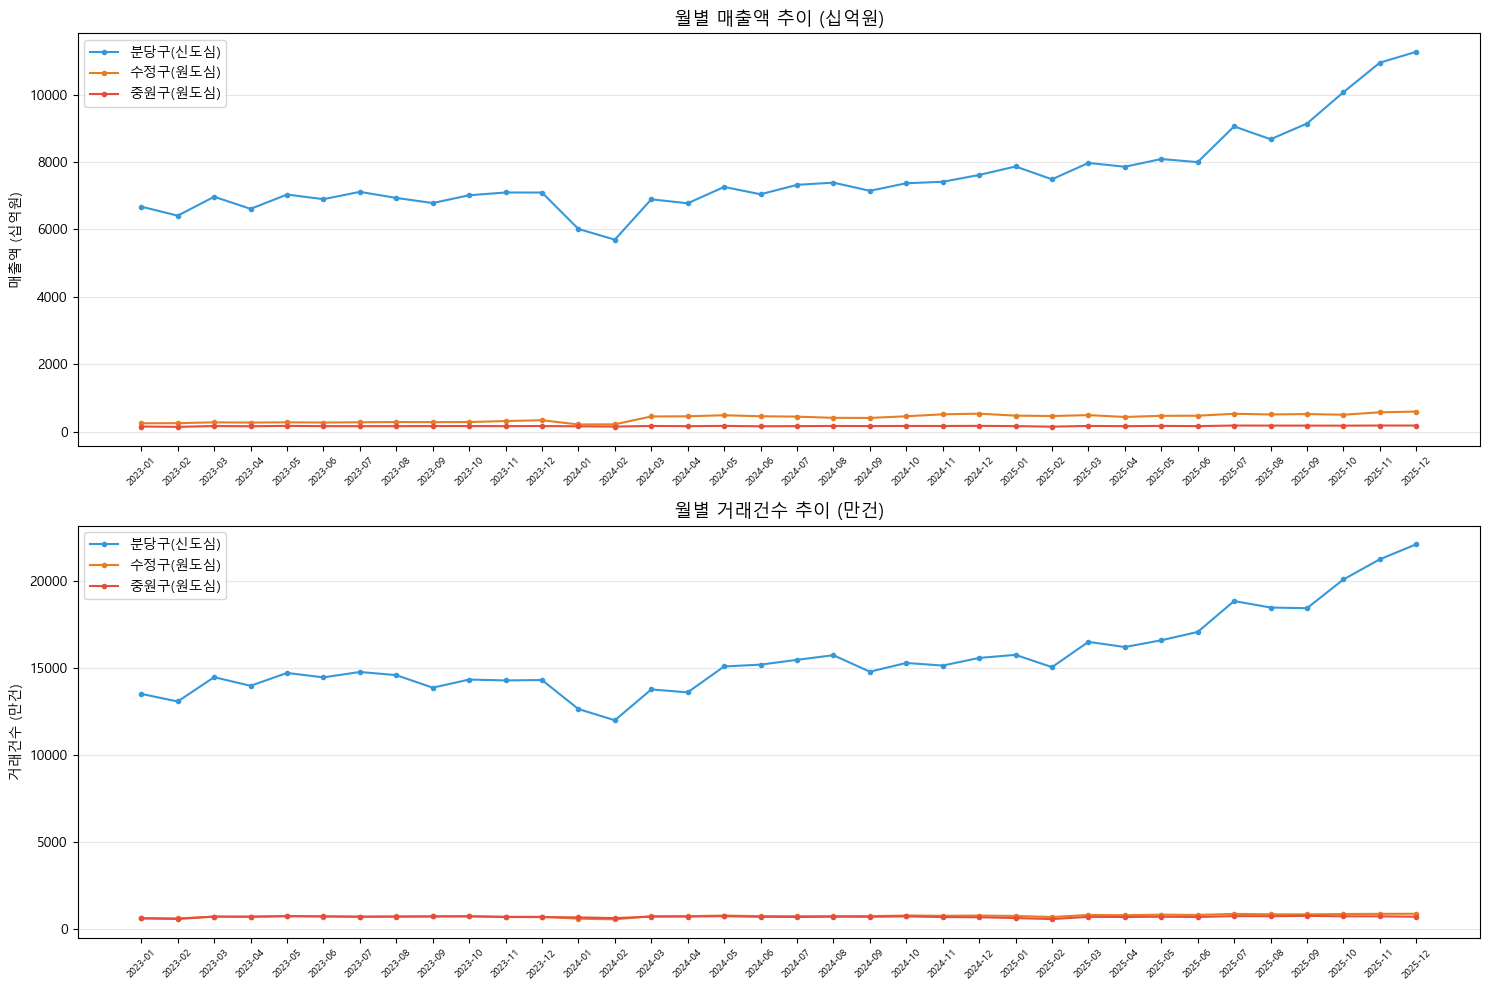

In [47]:
monthly_df = con.execute(f"""
    SELECT
        CAST(cty_rgn_no AS VARCHAR) AS cty_rgn_no,
        STRFTIME(CAST(ta_ymd AS DATE), '%Y-%m') AS ym,
        SUM(amt) AS 월매출액,
        SUM(cnt) AS 월거래건수
    FROM read_csv_auto('{SALES_PATH}', delim=',', header=True)
    WHERE CAST(cty_rgn_no AS VARCHAR) IN ('41131', '41133', '41135')
    GROUP BY cty_rgn_no, ym
    ORDER BY cty_rgn_no, ym
""").df()
monthly_df['지역'] = monthly_df['cty_rgn_no'].map(region_map)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for region, grp in monthly_df.groupby('지역'):
    color = '#e74c3c' if '중원구' in region else ('#e67e22' if '수정구' in region else '#3498db')
    axes[0].plot(grp['ym'], grp['월매출액'] / 1e9, marker='o', markersize=3, label=region, color=color)
    axes[1].plot(grp['ym'], grp['월거래건수'] / 1e4, marker='o', markersize=3, label=region, color=color)

for ax, title, ylabel in zip(axes,
    ['월별 매출액 추이 (십억원)', '월별 거래건수 추이 (만건)'],
    ['매출액 (십억원)', '거래건수 (만건)']):
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(ylabel)
    ax.legend()
    ticks = monthly_df['ym'].unique()
    ax.set_xticks(range(len(ticks)))
    ax.set_xticklabels(ticks, rotation=45, fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 행정동별 매출

In [5]:
sales_df = pd.read_csv(file_path+'/전처리완료_카드(매출).csv', encoding ='utf-8')
sales_df.head()

,ta_ymd,cty_rgn_no,admi_cty_no,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,hour,sex,age,day,amt,cnt
0,2023-01-01,41131,41131510,D01,소매/유통,가전제품,4,M,5,7,9251291,2
1,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,5,7,62392,4
2,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,6,7,153920,2
3,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,F,7,7,21515,2
4,2023-01-01,41131,41131510,D01,소매/유통,가전제품,5,M,6,7,544320,4


### 행정동 코드 - 행정동명 매핑

In [7]:
dong_master_df = pd.read_csv(file_path+"/seongnam_dong_master.csv", encoding = 'cp949')

In [8]:
dong_master_df['dong_code_8'] = dong_master_df['dong_code'].astype(str).str[:8]
dong_master_df.head(1)

,dong_code,dong_name,gu_code,gu_name,city_code,city_name,sort_order,use_yn,created_at,updated_at,dong_code_8
0,4113151000,신흥1동,41131,수정구,41130,성남시,1,Y,2026-04-17 08:19:16,2026-04-17 08:19:16,41131510


In [16]:
con = duckdb.connect()
con.register("s", sales_df)
con.register("m", dong_master_df)

sales_df_m = con.execute(f"""
    CREATE OR REPLACE VIEW sales_mapped AS
    SELECT
        s.ta_ymd, s.cty_rgn_no,
        m.gu_name,
        s.admi_cty_no,
        m.dong_name,
        s.card_tpbuz_cd, s.card_tpbuz_nm_1, s.card_tpbuz_nm_2,
        s.hour, s.sex, s.age, s.day, s.amt, s.cnt
    FROM s
    LEFT JOIN m ON s.admi_cty_no::VARCHAR = m.dong_code_8::VARCHAR
""")

#### 전체

In [17]:
result = con.execute("""
    SELECT ta_ymd, gu_name, dong_name, SUM(amt) AS 매출액, SUM(cnt) AS 거래건수
    FROM sales_mapped
    GROUP BY ta_ymd, gu_name, dong_name
    ORDER BY 매출액 DESC
""").df()

result.head()

,ta_ymd,gu_name,dong_name,매출액,거래건수
0,2025-12-01,분당구,정자1동,307002703779,4624083
1,2025-11-03,분당구,정자1동,301371909659,4501596
2,2025-11-11,분당구,정자1동,299665368136,4238140
3,2025-10-29,분당구,정자1동,297415953298,4147654
4,2025-10-13,분당구,정자3동,283472871592,5149024


#### 2025년 구별 동 단위 매출 top 5

In [33]:
# 2025년 분당구 카드소비 매출액 top 5
bundang_result_2025 = con.execute("""
    SELECT gu_name, dong_name, SUM(amt) AS 매출액
    FROM sales_mapped
    WHERE (LEFT(ta_ymd, 4) = '2025') and (gu_name = '분당구')
    GROUP BY gu_name, dong_name
    ORDER BY 매출액 DESC
""").df()

bundang_result_2025.head()

,gu_name,dong_name,매출액
0,분당구,정자1동,65126661659035
1,분당구,백현동,17019227874599
2,분당구,정자3동,7703485316044
3,분당구,서현1동,6084214049782
4,분당구,수내1동,6018618451504


#### 참고(도메인 조사)
| 지역명 | 위험 수준 | 위험 유형 | 주요 원인 및 현황 |
| :--- | :---: | :--- | :--- |
| **백현동** | **매우 높음** | 상업/업무 복합 | 판교역세권 및 카페거리 활성화, 현대백화점 등 거대 상권 형성으로 인한 최고 수준의 임대료 |
| **정자1동** | **높음** | 상업 젠트리피케이션 | 카페거리와 주상복합 밀집 지역. 지속적인 상권 재편과 대형 프랜차이즈 위주의 상점 교체 현상 뚜렷 |
| **서현1동** | **보통/주의** | 상업 고착화 | 분당 최대 전통 상권이나, 높은 임대료를 견딜 수 있는 업종만 살아남는 상권 필터링 현상 진행 중 |
| **수내1동** | **보통** | 주거/상업 안정 | 학군 및 주거 선호도가 매우 높아 임대료는 높으나, 급격한 변화보다는 안정적인 고가 상권 유지 |
| **정자3동** | **낮음/안정** | 주거 중심 | 정자1동에 비해 주거 밀집도가 높고 배후 수요가 탄탄하여 상권 변동이나 내몰림 현상이 상대적으로 적음 |

※분당 지역은 매출 규모(amt) 자체가 크기 때문에, '결제 건수(cnt) 대비 매출액'을 계산하여 객단가가 얼마나 가파르게 상승하는지 비교해 보면 젠트리피케이션 속도를 파악하기 좋다.

In [32]:
# 2025년 중원구 카드소비 매출액 top5
joongwon_result_2025 = con.execute("""
    SELECT gu_name, dong_name, SUM(amt) AS 매출액
    FROM sales_mapped
    WHERE (LEFT(ta_ymd, 4) = '2025') and (gu_name = '중원구')
    GROUP BY gu_name, dong_name
    ORDER BY 매출액 DESC
""").df()

joongwon_result_2025.head()

,gu_name,dong_name,매출액
0,중원구,상대원1동,3014096028543
1,중원구,도촌동,2030953975109
2,중원구,성남동,402112673259
3,중원구,하대원동,158918245178
4,중원구,금광2동,107852505364


#### 참고(도메인 조사)
| 지역명 | 위험 수준 | 위험 유형 | 주요 원인 및 현황 |
| :--- | :---: | :--- | :--- |
| **성남동** | **매우 높음** | 상업 젠트리피케이션 | 모란역-신흥역 상권 활성화 및 도시재생사업으로 인한 임대료 상승 압박 핵심지 |
| **금광2동** | **높음** | 주거 젠트리피케이션 | 공공주택 복합사업 및 인근 대단지 입주 여파로 인한 지가 상승 및 원주민 이탈 우려 |
| **상대원1동** | **보통** | 잠재적 젠트리피케이션 | 산업단지 배후지로 주거 정비사업 논의 단계이나 상업적 변동성은 상대적으로 완만함 |
| **하대원동** | **낮음/주의** | 국지적 젠트리피케이션 | 노후 주택가 소규모 정비사업 위주로 진행되며 대규모 내몰림 현상은 아직 미비함 |
| **도촌동** | **낮음** | 안정 지역 | 공공주택지구 기반의 안정된 주거 단지로 대규모 개발이나 상권 급변 이슈가 적음 |

In [30]:
# 2025년 수정구 카드소비 매출액 top5
sujeong_result_2025 = con.execute("""
    SELECT gu_name, dong_name, SUM(amt) AS 매출액
    FROM sales_mapped
    WHERE (LEFT(ta_ymd, 4) = '2025') and (gu_name = '수정구')
    GROUP BY gu_name, dong_name
    ORDER BY 매출액 DESC
""").df()

sujeong_result_2025.head()

,gu_name,dong_name,매출액
0,수정구,위례동,492604857534
1,수정구,태평4동,218330990256
2,수정구,수진2동,174092819486
3,수정구,신흥3동,150024388771
4,수정구,시흥동,142167963766


#### 참고(도메인 조사)
| 지역명 | 위험 수준 | 위험 유형 | 주요 원인 및 현황 |
| :--- | :---: | :--- | :--- |
| **신흥3동** | **매우 높음** | 주거 젠트리피케이션 | 성남형 재개발 2단계 구역으로 선정. 대규모 이주와 지가 상승으로 인한 원주민 내몰림 위험 직면 |
| **수진2동** | **높음** | 주거 젠트리피케이션 | 인근 수진1구역 등 대규모 재개발 시너지가 발생하는 인접지로, 임대료 상승 압박이 매우 거센 지역 |
| **태평4동** | **높음** | 복합 젠트리피케이션 | 도시재생 활성화 지역으로 주거 환경은 개선 중이나, 부동산 가치 상승에 따른 원주민 이탈 우려 지속 |
| **시흥동** | **특수** | 지가 상승 위험 | 판교 제2·3테크노밸리 확장 등 공공주도 개발이 집중되어 주거보다는 토지 가격 급등 성격이 강함 |
| **위례동** | **안정/유지** | - | 신도시 조성 후 상권과 주거 환경이 이미 높은 가격으로 고착화된 상태. 급격한 내몰림보다는 안정기 진입 |

#### 원도심 행정동별 매출

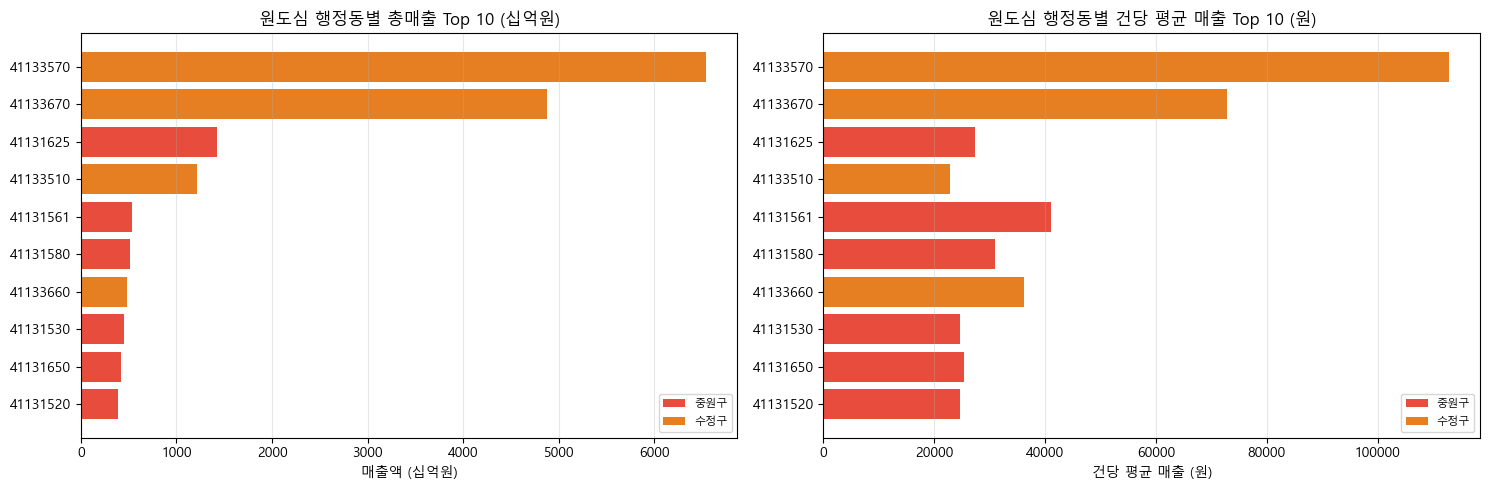

,admi_cty_no,지역,매출액,거래건수,건당평균매출
0,41133570,수정구(원도심),6.542188e+12,57999610.0,112797.101038
1,41133670,수정구(원도심),4.875869e+12,66911857.0,72870.028568
2,41131625,중원구(원도심),1.421200e+12,51854095.0,27407.671760
3,41133510,수정구(원도심),1.209973e+12,52945630.0,22853.126581
4,41131561,중원구(원도심),5.338174e+11,13007409.0,41039.486689
5,41131580,중원구(원도심),5.091564e+11,16464751.0,30924.027772
6,41133660,수정구(원도심),4.800790e+11,13286828.0,36131.950645
7,41131530,중원구(원도심),4.468651e+11,18151706.0,24618.351609
8,41131650,중원구(원도심),4.196998e+11,16516651.0,25410.710761
9,41131520,중원구(원도심),3.845021e+11,15559385.0,24711.908217


In [49]:
dong_df = con.execute(f"""
    SELECT
        CAST(cty_rgn_no AS VARCHAR) AS cty_rgn_no,
        CAST(admi_cty_no AS VARCHAR) AS admi_cty_no,
        SUM(amt) AS 매출액,
        SUM(cnt) AS 거래건수,
        SUM(amt) / NULLIF(SUM(cnt), 0) AS 건당평균매출
    FROM read_csv_auto('{SALES_PATH}', delim=',', header=True)
    WHERE CAST(cty_rgn_no AS VARCHAR) IN ('41131', '41133')
    GROUP BY cty_rgn_no, admi_cty_no
    ORDER BY 매출액 DESC
    LIMIT 10
""").df()
dong_df['지역'] = dong_df['cty_rgn_no'].map(region_map)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_bar = ['#e74c3c' if '중원구' in r else '#e67e22' for r in dong_df['지역']]

axes[0].barh(dong_df['admi_cty_no'], dong_df['매출액'] / 1e9, color=colors_bar)
axes[0].set_title('원도심 행정동별 총매출 Top 10 (십억원)')
axes[0].set_xlabel('매출액 (십억원)')
axes[0].invert_yaxis()

axes[1].barh(dong_df['admi_cty_no'], dong_df['건당평균매출'], color=colors_bar)
axes[1].set_title('원도심 행정동별 건당 평균 매출 Top 10 (원)')
axes[1].set_xlabel('건당 평균 매출 (원)')
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='중원구'), Patch(facecolor='#e67e22', label='수정구')]
for ax in axes:
    ax.legend(handles=legend_elements, fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
display(dong_df[['admi_cty_no', '지역', '매출액', '거래건수', '건당평균매출']])

In [53]:
dong_10 = dong_df[['admi_cty_no', '지역', '매출액', '거래건수', '건당평균매출']]
dong_dict = dong_master_df.set_index('dong_code_8')['dong_name'].to_dict()

dong_10['dong_name'] = dong_10['admi_cty_no'].map(dong_dict)
dong_10

,admi_cty_no,지역,매출액,거래건수,건당평균매출,dong_name
0,41133570,수정구(원도심),6.542188e+12,57999610.0,112797.101038,상대원1동
1,41133670,수정구(원도심),4.875869e+12,66911857.0,72870.028568,도촌동
2,41131625,중원구(원도심),1.421200e+12,51854095.0,27407.671760,위례동
3,41133510,수정구(원도심),1.209973e+12,52945630.0,22853.126581,성남동
4,41131561,중원구(원도심),5.338174e+11,13007409.0,41039.486689,태평4동
5,41131580,중원구(원도심),5.091564e+11,16464751.0,30924.027772,수진2동
6,41133660,수정구(원도심),4.800790e+11,13286828.0,36131.950645,하대원동
7,41131530,중원구(원도심),4.468651e+11,18151706.0,24618.351609,신흥3동
8,41131650,중원구(원도심),4.196998e+11,16516651.0,25410.710761,시흥동
9,41131520,중원구(원도심),3.845021e+11,15559385.0,24711.908217,신흥2동


#### 참고(도메인 조사)

| 지역명 | 위험 수준 | 위험 유형 | 주요 원인 및 현황 |
| :--- | :---: | :--- | :--- |
| **신흥3동** | **매우 높음** | 주거 젠트리피케이션 | 2023년 정비구역 지정, 성남형 재개발 2단계 본격화로 인한 원주민 밀려남 우려 |
| **수진2동** | **높음** | 주거 젠트리피케이션 | 인근 재개발 구역(수진1) 파급효과 및 원도심 이주 수요 집중으로 인한 임대료 상승 |
| **태평4동** | **높음** | 복합 젠트리피케이션 | 근린재생형 도시재생 활성화 지역으로, 환경 개선에 따른 지가 상승 및 원주민 이탈 가능성 |
| **성남동(수정구)** | **보통/주의** | 상업 젠트리피케이션 | 산성대로 도시재생 사업지구 포함. 상권 활성화에 따른 임대료 상승(상생 협약 체결지) |
| **신흥2동(중원구)** | **보통/주의** | 상업 젠트리피케이션 | 대규모 신축 아파트 입주 후 주변 상권 재편 및 프랜차이즈 유입 가속화 |
| **상대원1동** | **낮음/잠재** | 주거 젠트리피케이션 | 산업단지 배후 주거지로, 향후 노후 주택 정비사업 논의 시 위험도 상승 가능성 |
| **하대원동** | **낮음/잠재** | 주거 젠트리피케이션 | 원도심 외곽 지역이나 최근 소규모 가로주택정비사업 등으로 인한 국지적 변동성 |
| **위례동** | **안정** | - | 신도시 조성 완료 단계. 이미 높은 임대료가 형성되어 있어 발생 단계보다 유지 단계 |
| **시흥동** | **특수** | 지가 상승 위험 | 판교 제2테크노밸리 확장 영향권이나, 일반 주거지보다는 업무지구 확장 성격 |
| **도촌동** | **안정** | - | 공공주택지구 위주의 주거지로 상권 변화나 재개발 이슈가 적어 위험도 낮음 |